In [1]:
import sys
sys.path.append('../../')
from qufold import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, dcd_ansatz, commutator_funcs
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [2]:
# Some utility functions for the problem

def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""
    # Define the interaction
    side_chains = [""] * len(main_seq)

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)

    penalty_back = 10
    penalty_chiral = 10
    penalty_1 = 10

    penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)

    peptide = Peptide(main_seq, side_chains)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem


def classify_amino_acids(sequence):
    hydrophobic = set('GAVLIPFMW')
    return ''.join('H' if amino in hydrophobic else 'P' for amino in sequence)


In [3]:

from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.quantum_info import commutator

def mixer_op_x(n, theta: np.pi):
    # Theta = pi for standard X Pauli
    rx_terms = []
    for i in range(n):
        # Create a Pauli string with X on the i-th qubit and I on the others
        labels = ['I'] * n
        labels[i] = 'X'
        pauli_string = ''.join(labels)
        pauli_op = SparsePauliOp(Pauli(pauli_string), coeffs=[theta/2])
        rx_terms.append(pauli_op)
    mixer_hamiltonian = sum(rx_terms, start=SparsePauliOp.from_list([('I'*n, 0)]))
    return mixer_hamiltonian


def truncate_to_two_local(pauli_op, return_output=True):
    # Extract labels and coefficients
    labels = pauli_op.paulis.to_labels()
    coeffs = pauli_op.coeffs
    # Initialize list to collect the filtered terms
    filtered_labels = []
    filtered_coeffs = []
    # Filter terms to include only those with exactly one or two non-identity operators ('X', 'Y', 'Z')
    for label, coeff in zip(labels, coeffs):
        # Count the number of non-identity Pauli operators
        non_identity_count = sum(1 for char in label if char != 'I')

        # Filter to include only one-weight and two-weight terms
        if non_identity_count == 1 or non_identity_count == 2:
            filtered_labels.append(label)
            filtered_coeffs.append(coeff)
    
    # Construct the new SparsePauliOp if there are any valid terms
    if filtered_labels:
        truncated_terms = SparsePauliOp.from_list(list(zip(filtered_labels, filtered_coeffs)))
    else:
        # Return an empty operator if no terms meet the criteria
        truncated_terms = SparsePauliOp.from_list([('I' * pauli_op.num_qubits, 0)])
    
    # Optionally return the result
    if return_output:
        return truncated_terms
    else:
        # The output can be captured in a variable 'U_cd' for later use without being returned
        U_cd = truncated_terms
        # Optionally print or log the variable for verification or debugging
        # print("U_cd stored:", U_cd)
        pass


def calculate_commutator(hamiltonian, truncate: bool, order: int):
    mixer_op = mixer_op_x(hamiltonian.num_qubits, np.pi)  # Regular Pauli X mixer
    # Set up the Hamiltonians
    H_a = 0.5 * mixer_op + 0.5 * hamiltonian
    partial_H_a = -mixer_op + hamiltonian

    # Start with the first commutator
    current_commutator = commutator(H_a, partial_H_a).simplify()
    
    # Compute nested commutators up to the specified order
    for _ in range(order - 1):
        current_commutator = commutator(H_a, current_commutator).simplify()
    
    if truncate:
        # If truncation is needed, filter to two-local terms with specific Pauli characters
        final_hamiltonian = truncate_to_two_local(current_commutator).simplify()
    else:
        # If no truncation is needed, use the final commutator result
        final_hamiltonian = current_commutator

    return final_hamiltonian

In [4]:
main_chain = "YYDPETGTWY" # 10 AA chingolin
pf = build_pf(main_chain, "mj_matrix")
qubit_op = pf.qubit_op()

In [15]:
from qiskit.quantum_info import SparsePauliOp
from collections import Counter

def analyze_pauli_terms(pauli_op: SparsePauliOp):
    # Extract labels from the Pauli operator
    labels = pauli_op.paulis.to_labels()
    
    # Initialize a Counter to store occurrences of each Pauli term type
    term_types = Counter()
    
    # Iterate over each label and process
    # Skip the sorting to keep 'XZ' and 'ZX' distinct
    for label in labels:
        # Remove identity matrices, keep the order of non-identity Pauli matrices
        normalized_label = label.replace('I', '')
        if normalized_label == '':
            normalized_label = 'I'  # Include identity as a term if all are 'I'
        term_types[normalized_label] += 1
    
    # Return a dictionary of term types with their counts
    return dict(term_types)




In [16]:
dcd_hamiltonian = calculate_commutator(qubit_op, True, 2)
analyze_pauli_terms(dcd_hamiltonian)

{'X': 22,
 'Z': 22,
 'ZZ': 119,
 'YY': 119,
 'Y': 8,
 'YZ': 9,
 'ZY': 10,
 'ZX': 150,
 'XZ': 129}

In [17]:
dcd_hamiltonian.size

588

In [8]:
from qiskit.quantum_info import SparsePauliOp, Pauli

def select_terms(dcd_hamiltonian, term_analysis, num_qubits):
    # Extract labels and coefficients
    labels = dcd_hamiltonian.paulis.to_labels()
    coeffs = dcd_hamiltonian.coeffs
    
    # Determine the weight-2 term with the lowest count
    lowest_count = float('inf')
    lowest_term_type = None
    for term, count in term_analysis.items():
        if len(term) == 2 and count < lowest_count:
            lowest_count = count
            lowest_term_type = term

    # Initialize a list to collect the selected terms with their coefficients
    selected_terms = []
    
    # Filter the terms based on the analysis
    for label, coeff in zip(labels, coeffs):
        normalized_label = ''.join(sorted(label.replace('I', '')))
        
        # Select weight-1 terms where the count matches the number of qubits
        if normalized_label in term_analysis and len(normalized_label) == 1 and term_analysis[normalized_label] == num_qubits:
            selected_terms.append((label, coeff))
        
        # Select weight-2 terms of the type with the lowest count
        elif normalized_label == lowest_term_type:
            selected_terms.append((label, coeff))

    # Return a new SparsePauliOp with the selected terms
    return SparsePauliOp.from_list(selected_terms)


In [9]:
dcd_hamiltonian.paulis

PauliList(['XIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIIIIIIII',
           'IXIIIIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIIII',
           'IZIIIIIIIIIIIIIIIIIZII', 'IZIIIIIIIIIIIIIIIZIIII',
           'IZIIIIIIIIIIIIIZIIIIII', 'IZIIIIIIIIIIIZIIIIIIII',
           'IZIIIIIIIIIZIIIIIIIIII', 'IYIIIIIIIIIYIIIIIIIIII',
           'IYIIIIIIIIIIIYIIIIIIII', 'IYIIIIIIIIIIIIIYIIIIII',
           'IYIIIIIIIIIIIIIIIYIIII', 'IYIIIIIIIIIIIIIIIIIYII',
           'IIXIIIIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIIII',
           'IIZIIIIIIIIIIIIIIIIZII', 'IIZIIIIIIIIIIIIIIZIIII',
           'IIZIIIIIIIIIIIIZIIIIII', 'IIZIIIIIIIIIIZIIIIIIII',
           'IIZIIIIIIIIZIIIIIIIIII', 'IIZIIIIIIZIIIIIIIIIIII',
           'IIZIIIIIIIIIIIIIIIIIZI', 'IIZIIIIIIIIIIIIIIIZIII',
           'IIZIIIIIIIIIIIIIZIIIII', 'IIZIIIIIIIIIIIZIIIIIII',
           'IIZIIIIIIIIIZIIIIIIIII', 'IIZIIIIIIIZIIIIIIIIIII',
           'IIYIIIIIIYIIIIIIIIIIII', 'IIYIIIIIIIYIIIIIIIIIII',
           'IIYIIIIIIIIYIIIIIIIIII', 'IIYIIIIIIIIIYIIII

In [10]:
optimal_dcd_selection = select_terms(dcd_hamiltonian, analyze_pauli_terms(dcd_hamiltonian), qubit_op.num_qubits)

In [11]:
optimal_dcd_selection.paulis

PauliList(['XIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIIIIIIIII',
           'IXIIIIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIIII',
           'IIXIIIIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIIII',
           'IIIXIIIIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIIIII',
           'IIIIXIIIIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIIIII',
           'IIIIIXIIIIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIIIII',
           'IIIIIIXIIIIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIIII',
           'IIIIIIIXIIIIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIIII',
           'IIIIIIIIXIIIIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIIII',
           'IIIIIIIIIXIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIIII',
           'IIIIIIIIIIXIIIIIIIIIII', 'IIIIIIIIIIZIIIIIIIIIII',
           'IIIIIIIIIIIXIIIIIIIIII', 'IIIIIIIIIIIZIIIIIIIIII',
           'IIIIIIIIIIIIXIIIIIIIII', 'IIIIIIIIIIIIZIIIIIIIII',
           'IIIIIIIIIIIIIXIIIIIIII', 'IIIIIIIIIIIIIZIIIIIIII',
           'IIIIIIIIIIIIIIXIIIIIII', 'IIIIIIIIIIIIIIZIIIIIII',
           'IIIIIIIIIIIIIIIXIIIIII', 'IIIIIIIIIIIIIIIZI

In [12]:
ansatz = dcd_ansatz.dig_count_ansatz(optimal_dcd_selection) #choose your ansatz
num_params = ansatz.num_parameters

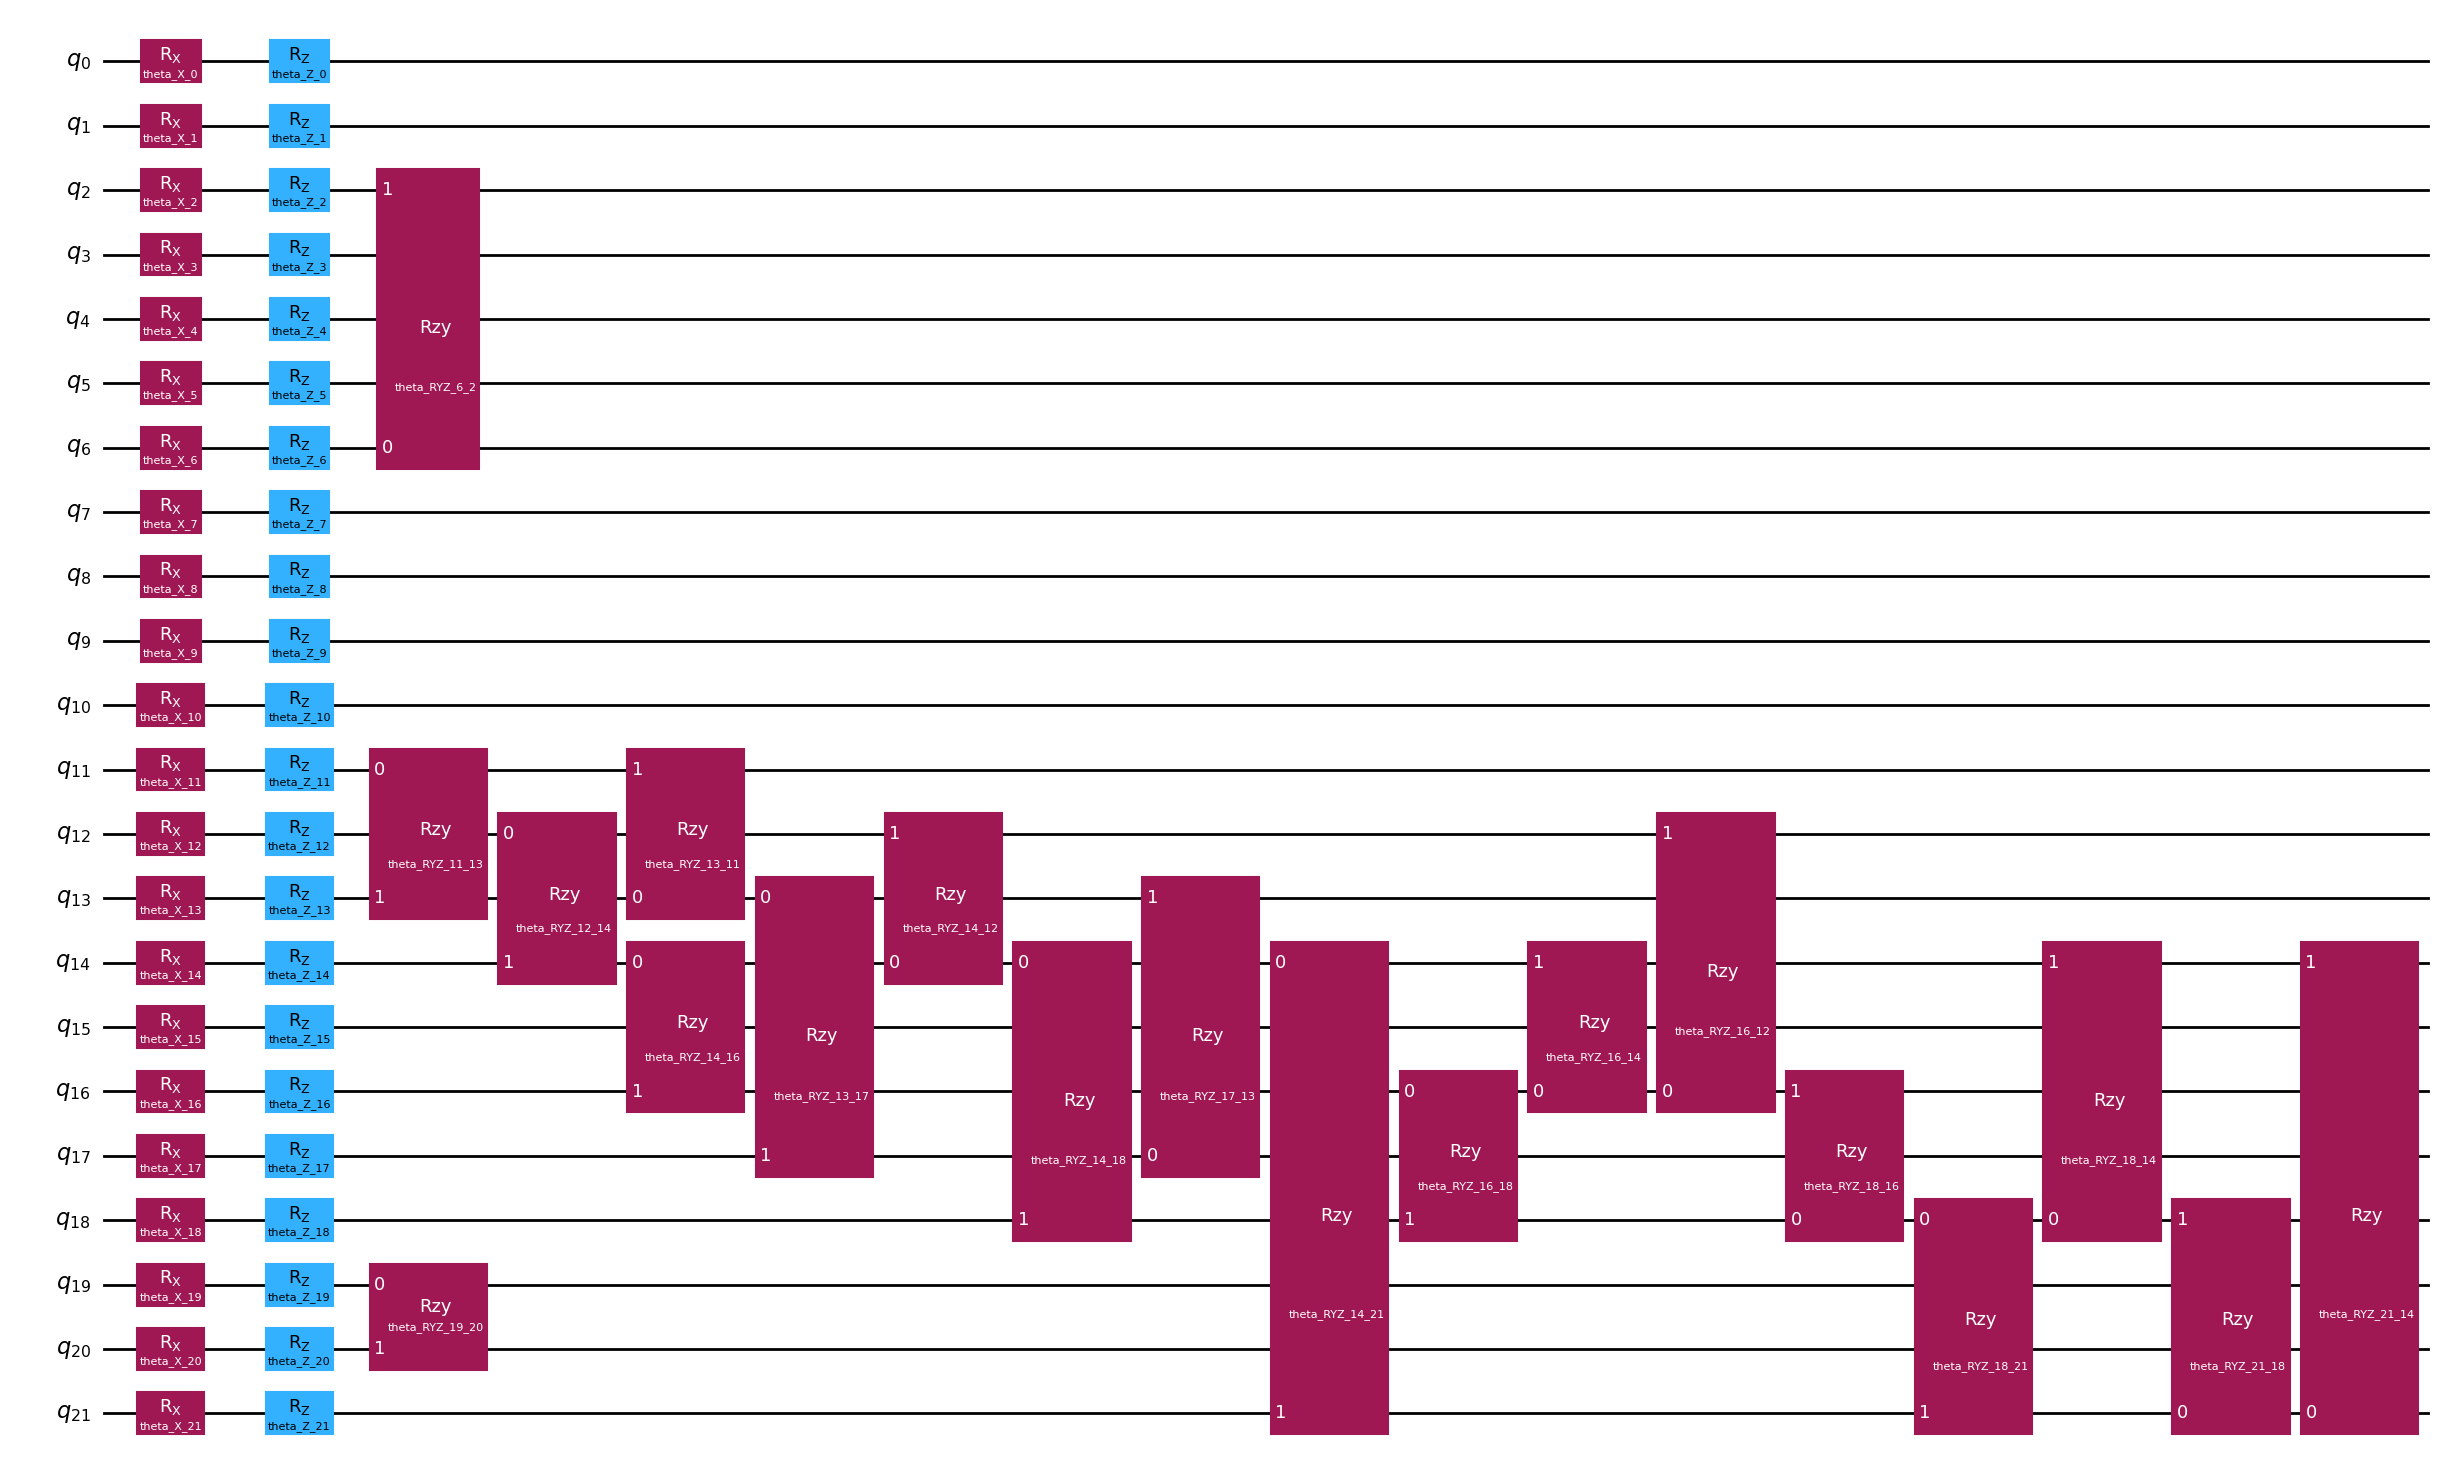

In [13]:
ansatz.draw('mpl', fold=-1)

In [14]:
ansatz.count_ops()

OrderedDict([('rx', 22), ('rz', 22), ('rzy', 19)])